In [43]:
# import libraries
import pandas as pd
import seaborn as sns
import numpy as np

import matplotlib
import matplotlib.pyplot as plt
plt.style.use('ggplot')
from matplotlib.pyplot import figure

%matplotlib inline
matplotlib.rcParams['figure.figsize'] = (12, 8)

# import data
df = pd.read_csv(r'C:\Users\sata\Downloads\movies.csv')
df_test1 = df.copy()

In [44]:
df.head()

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000.0,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000.0,46998772.0,Warner Bros.,146.0
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000.0,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000.0,58853106.0,Columbia Pictures,104.0
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000.0,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000.0,538375067.0,Lucasfilm,124.0
3,Airplane!,PG,Comedy,1980,"July 2, 1980 (United States)",7.7,221000.0,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000.0,83453539.0,Paramount Pictures,88.0
4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7.3,108000.0,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000.0,39846344.0,Orion Pictures,98.0


In [45]:
#check for missing data
missing = (df.isnull().mean() * 100).sort_values(ascending=False)
print(missing.round(2))

budget      28.31
gross        2.46
rating       1.00
company      0.22
runtime      0.05
score        0.04
votes        0.04
writer       0.04
country      0.04
released     0.03
star         0.01
name         0.00
genre        0.00
year         0.00
director     0.00
dtype: float64


In [46]:
#fill missing values
df_test1['budget'] = df_test1['budget'].fillna(df_test1['budget'].median())
df_test1 = df_test1.dropna(subset=['gross'])

#change columns data type
df_test1['budget'] = df_test1['budget'].astype('int64')
df_test1['gross'] = df_test1['gross'].astype('int64')

#view data
df_test1[['budget', 'gross']].info()
df_test1[['budget', 'gross']].head()


<class 'pandas.core.frame.DataFrame'>
Index: 7479 entries, 0 to 7659
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   budget  7479 non-null   int64
 1   gross   7479 non-null   int64
dtypes: int64(2)
memory usage: 175.3 KB


,budget,gross
0,19000000,46998772
1,4500000,58853106
2,18000000,538375067
3,3500000,83453539
4,6000000,39846344


In [47]:
df_test1.head()

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000.0,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000,46998772,Warner Bros.,146.0
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000.0,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000,58853106,Columbia Pictures,104.0
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000.0,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000,538375067,Lucasfilm,124.0
3,Airplane!,PG,Comedy,1980,"July 2, 1980 (United States)",7.7,221000.0,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000,83453539,Paramount Pictures,88.0
4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7.3,108000.0,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000,39846344,Orion Pictures,98.0


In [48]:
#sheck the result
missing = (df_test1.isnull().mean() * 100).sort_values(ascending=False)
print(missing.round(2))

rating      0.72
company     0.13
writer      0.04
country     0.01
runtime     0.01
name        0.00
genre       0.00
year        0.00
released    0.00
score       0.00
votes       0.00
director    0.00
star        0.00
budget      0.00
gross       0.00
dtype: float64


In [49]:
#columns data type
df_test1.dtypes

name         object
rating       object
genre        object
year          int64
released     object
score       float64
votes       float64
director     object
writer       object
star         object
country      object
budget        int64
gross         int64
company      object
runtime     float64
dtype: object

In [50]:
df_test1[['released']].head()

,released
0,"June 13, 1980 (United States)"
1,"July 2, 1980 (United States)"
2,"June 20, 1980 (United States)"
3,"July 2, 1980 (United States)"
4,"July 25, 1980 (United States)"


In [51]:
#create correct year column
df_test1['yearcorrect'] = df_test1['released'].str.extract(r'(\d{4})')
df_test1['yearcorrect']

0       1980
1       1980
2       1980
3       1980
4       1980
        ... 
7653    2020
7655    2020
7656    2020
7657    2020
7659    2020
Name: yearcorrect, Length: 7479, dtype: object

In [56]:
df_test1 = df_test1.sort_values(by=['gross'], inplace=False, ascending= False)
df_test1.head()

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime,yearcorrect
5445,Avatar,PG-13,Action,2009,"December 18, 2009 (United States)",7.8,1100000.0,James Cameron,James Cameron,Sam Worthington,United States,237000000,2847246203,Twentieth Century Fox,162.0,2009
7445,Avengers: Endgame,PG-13,Action,2019,"April 26, 2019 (United States)",8.4,903000.0,Anthony Russo,Christopher Markus,Robert Downey Jr.,United States,356000000,2797501328,Marvel Studios,181.0,2019
3045,Titanic,PG-13,Drama,1997,"December 19, 1997 (United States)",7.8,1100000.0,James Cameron,James Cameron,Leonardo DiCaprio,United States,200000000,2201647264,Twentieth Century Fox,194.0,1997
6663,Star Wars: Episode VII - The Force Awakens,PG-13,Action,2015,"December 18, 2015 (United States)",7.8,876000.0,J.J. Abrams,Lawrence Kasdan,Daisy Ridley,United States,245000000,2069521700,Lucasfilm,138.0,2015
7244,Avengers: Infinity War,PG-13,Action,2018,"April 27, 2018 (United States)",8.4,897000.0,Anthony Russo,Christopher Markus,Robert Downey Jr.,United States,321000000,2048359754,Marvel Studios,149.0,2018


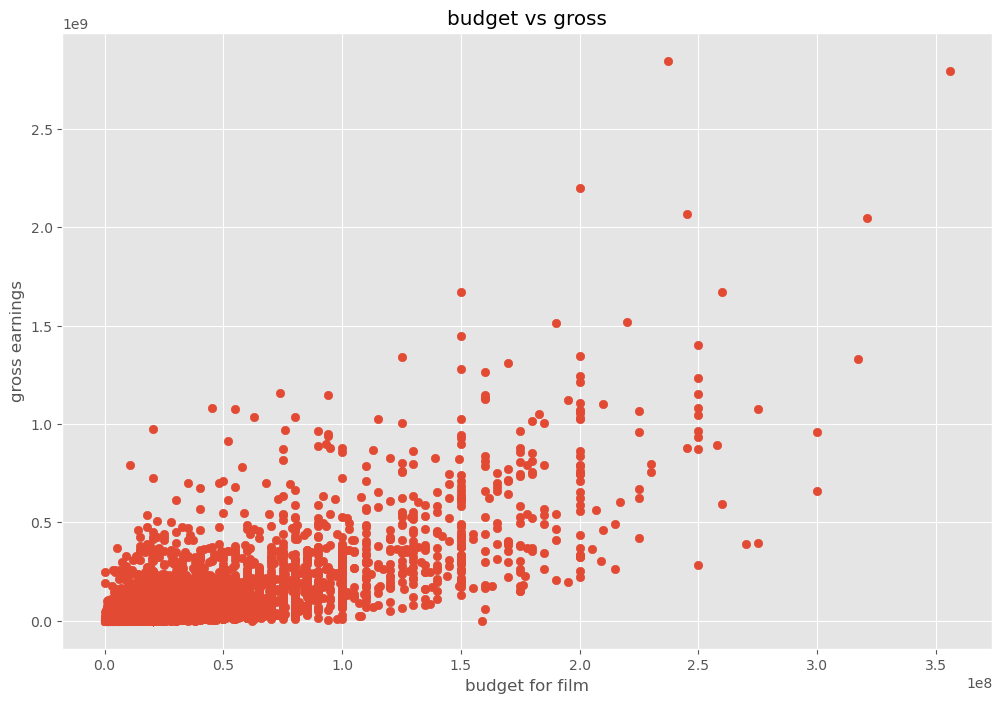

In [57]:
#scatter plot to show correlation between gross and budget
plt.scatter(x=df_test1['budget'], y=df_test1['gross'])
plt.title('budget vs gross')
plt.xlabel('budget for film')
plt.ylabel('gross earnings')
plt.show()

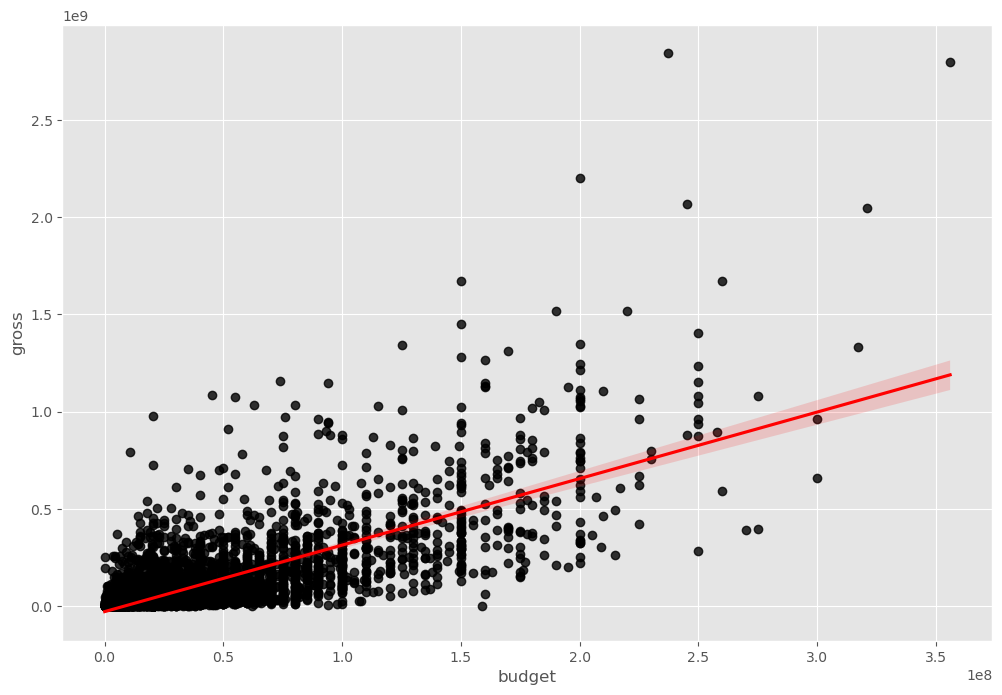

In [59]:
#plot budget vs gross using linear regression
sns.regplot(x='budget', y='gross', data=df_test1, scatter_kws={'color': 'black'}, line_kws={'color': 'red'})
plt.show()

In [68]:
#correlation in our data
correlation_df = df_test1.corr(method='pearson', numeric_only= True)
correlation_df

,year,score,votes,budget,gross,runtime
year,1.000000,0.091821,0.215740,0.289548,0.257486,0.114706
score,0.091821,1.000000,0.413096,0.058121,0.186258,0.397321
votes,0.215740,0.413096,1.000000,0.458372,0.630757,0.309536
budget,0.289548,0.058121,0.458372,1.000000,0.745552,0.272963
gross,0.257486,0.186258,0.630757,0.745552,1.000000,0.245216
runtime,0.114706,0.397321,0.309536,0.272963,0.245216,1.000000


In [67]:
# high correlation between gross and budget

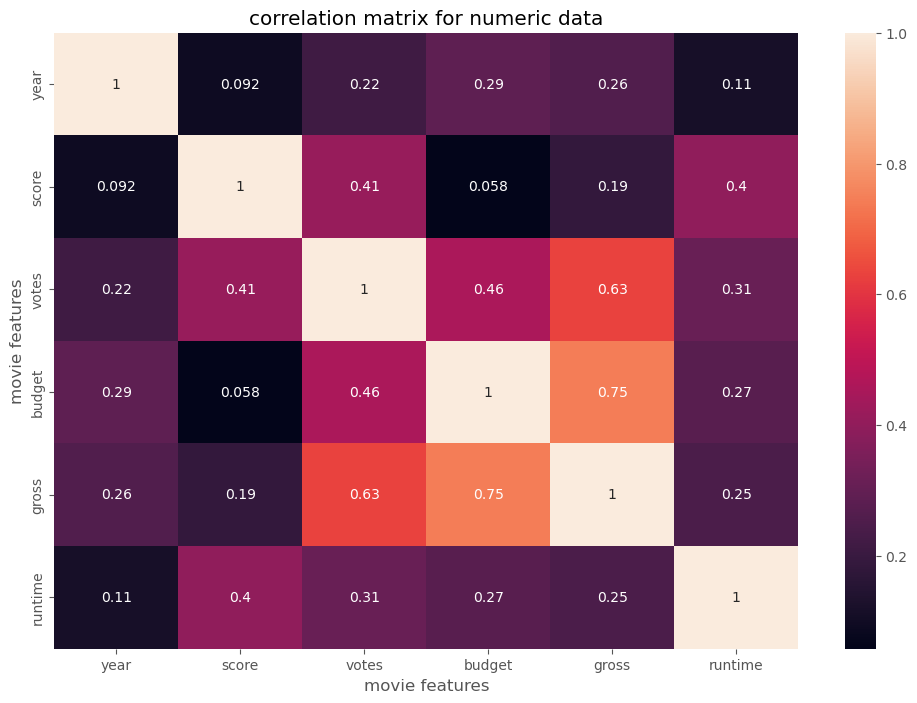

In [70]:
# plot heatmap to show correlation
sns.heatmap(correlation_df, annot= True)
plt.title('correlation matrix for numeric data')
plt.xlabel('movie features')
plt.ylabel('movie features')
plt.show()

In [71]:
df_numerized = df_test1

for col_name in df_numerized.columns:
    if(df_numerized[col_name].dtype == 'object'):
        df_numerized[col_name] = df_numerized[col_name].astype('category').cat.codes

df_numerized

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime,yearcorrect
5445,519,5,0,2009,683,7.8,1100000.0,1116,1719,2233,53,237000000,2847246203,2148,162.0,29
7445,521,5,0,2019,179,8.4,903000.0,161,717,2141,53,356000000,2797501328,1532,181.0,39
3045,6727,5,6,1997,691,7.8,1100000.0,1116,1719,1524,53,200000000,2201647264,2148,194.0,17
6663,5008,5,0,2015,685,7.8,876000.0,1086,2468,504,53,245000000,2069521700,1470,138.0,35
7244,522,5,0,2018,188,8.4,897000.0,161,717,2141,53,321000000,2048359754,1532,149.0,38
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3818,3268,6,4,2000,1097,6.5,5200.0,711,1085,2218,52,20500000,1400,463,103.0,21
7625,6559,-1,4,2019,1125,5.7,320.0,2459,2483,1830,53,20500000,790,2202,104.0,39
7580,4540,3,5,2019,1796,5.2,735.0,1403,2135,2177,53,20500000,682,1901,93.0,40
2417,3309,-1,6,1993,83,7.3,5100.0,33,1660,2453,27,11900000,596,764,134.0,13


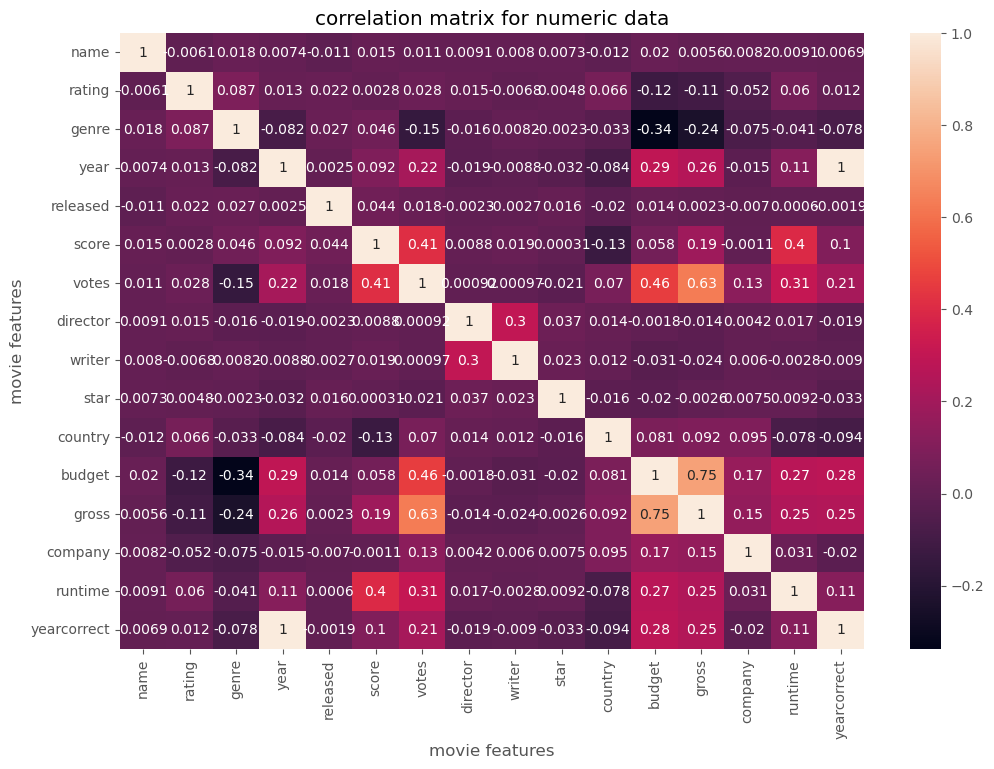

In [73]:
df_num_correlation = df_numerized.corr()
sns.heatmap(df_num_correlation, annot= True)
plt.title('correlation matrix for numeric data')
plt.xlabel('movie features')
plt.ylabel('movie features')
plt.show()